In [ ]:
import rioxarray as rio
import xarray as xr
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.ticker

import matplotlib.path as mpath
from matplotlib_scalebar.scalebar import ScaleBar
import cartopy as ctp

from scipy.integrate import trapezoid

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import netCDF4 as nc
import os


#import netCDF4 as nc
#import xarray as xr
#import rioxarray as rio
#import rasterio as rs
#import h5py
#import geopandas as gpd
#import fiona
from PIL import Image
Image.MAX_IMAGE_PIXELS = None # Needed to prevent a DecompressionBombError for high-resolution images
#import pandas as pd
import numpy as np
import os
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import datetime
import pandas as pd

from matplotlib.dates import DateFormatter, DayLocator
from obspy.imaging.util import _set_xaxis_obspy_dates

from matplotlib import rc
import matplotlib.font_manager as fm
#rc('text', usetex=True)
rc('font', size=8)
#rc('font', **{'family': 'sans-serif', 'sans-serif': ['Computer Modern']}) #change to computer modern for closer match with JGR?
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})
one_col = 3.35 #inches
two_col = 7.0 #inches

In [2]:
from obspy.core.inventory import inventory
import os

local_path = '/Users/jmagyar/Documents/TottenData'
cloud_path = '/Users/jmagyar/Library/Mobile Documents/com~apple~CloudDocs/Outputs/Icequakes'

stat_path = os.path.join(local_path,'stations/1J.TI??..???.xml')

inv = inventory.read_inventory(stat_path,level='response').select(station='TI?A',channel='??Z')

network_lst = []
station_lst = []
lat_lst = []
lon_lst = []
for network in inv:
    for station in network:
        network_lst.append(network.code)
        station_lst.append(station.code)
        lat_lst.append(station.latitude)
        lon_lst.append(station.longitude)

station_df = pd.DataFrame({'Network':network_lst,'Station':station_lst,'Latitude':lat_lst,'Longitude':lon_lst})
centre = (station_df['Longitude'].mean(),station_df['Latitude'].mean())

tide_lat = -67.25
tide_lon = 114.5

casey_lat = -66.2821
casey_lon = 110.5285

In [3]:
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import matplotlib.pyplot as plt
import numpy as np

# Make custom colormap for BedMachine bed topography
# N.B. using LinearSegmentedColormap to manually set colors at key anchor values, then interpolating inbetween
def cmap_bedmachine():
  colors = [
    (17/256, 29/256, 57/256), # Dark blue
    (59/256, 89/256, 130/256), # Navy blue
    (102/256, 172/256, 222/256), # Baby blue
    (255/256, 255/256, 255/256), # White
    (58/256, 97/256, 39/256), # Dark green
    (93/256, 156/256, 63/256), # Green
    (195/256, 180/256, 79/256), # Yellow
    (107/256, 82/256, 0), # Brown
    (52/256 ,37/256, 0) # Dark brown
  ]
  values = [-3000, -1000, -500, 0, 1, 500, 1000, 1500, 3000]
  norm = plt.Normalize(min(values), max(values))
  cmapping = list(zip(norm(values), colors))
  custom_cmap = LinearSegmentedColormap.from_list(name = 'BedMachine', colors = cmapping)
  return custom_cmap

# Make custom colormap for geological units in GeoMAP
# N.B. Mapping categorical values from column 'LITHCODE' or 'SIMPCODE' to specific colors & then setting them as a colormap via ListedColormap - Simply run print(geomap_data['COL_NAME'].unique()) to see the unique values in each column
def cmap_geomap(category):
  if category == 'LITHCODE':
    # For 'LITHCODE', explicitly set RGBA values (actually according to QGIS styling provided by dataset)
    color_dict = {'': np.array([190/256, 210/256, 255/256, 255/256]),
                  'c': np.array([255/256, 255/256, 0, 255/256]),
                  'j': np.array([76/256, 230/256, 0, 255/256]),
                  'l': np.array([76/256, 230/256, 0, 255/256]),
                  's': np.array([76/256, 230/256, 0, 255/256]),
                  'w': np.array([76/256, 230/256, 0, 255/256]),
                  'a': np.array([255/256, 0, 0, 255/256]),
                  'b': np.array([255/256, 0, 0, 255/256]),
                  'f': np.array([255/256, 0, 0, 255/256]),
                  'v': np.array([255/256, 0, 0, 255/256]),
                  'd': np.array([255/256, 115/256, 223/256, 255/256]),
                  'g': np.array([255/256, 115/256, 223/256, 255/256]),
                  'i': np.array([255/256, 115/256, 223/256, 255/256]),
                  'u': np.array([255/256, 115/256, 223/256, 255/256]),
                  'h': np.array([255/256, 115/256, 223/256, 255/256]),
                  'e': np.array([122/256, 142/256, 245/256, 255/256]),
                  'm': np.array([122/256, 142/256, 245/256, 255/256]),
                  'o': np.array([122/256, 142/256, 245/256, 255/256]),
                  't': np.array([122/256, 142/256, 245/256, 255/256]),
                  'y': np.array([122/256, 142/256, 245/256, 255/256]),
                  'p': np.array([122/256, 142/256, 245/256, 255/256]),
                  'n': np.array([132/256, 0, 168/256, 255/256]),
                  'q': np.array([132/256, 0, 168/256, 255/256]),
                  'x': np.array([132/256, 0, 168/256, 255/256]),
                  'z': np.array([132/256, 0, 168/256, 255/256]),
                  '?': np.array([78/256, 78/256, 78/256, 255/256])}
  elif category == 'SIMPCODE':
    # You can also just set some random named color strings - let's do this for 'SIMPCODE'
    color_dict = {10: 'lightblue',
                  11: 'blue',
                  20: 'turquoise',
                  21: 'green',
                  22: 'forestgreen',
                  23: 'yellowgreen',
                  30: 'yellow',
                  31: 'gold',
                  32: 'orange',
                  40: 'orangered',
                  41: 'coral',
                  42: 'red',
                  43: 'maroon',
                  44: 'brown',
                  45: 'chocolate',
                  50: 'pink',
                  60: 'orchid',
                  61: 'violet',
                  62: 'indigo',
                  63: 'grey',
                  70: 'black'}
  else:
    return "Invalid column label given! Pick 'LITHCODE' or 'SIMPCODE'."
  custom_cmap = ListedColormap(list(color_dict.values()))
  return custom_cmap

In [4]:
directory = '/Users/jmagyar/Documents/MappingProducts/'
bedmachine_file = directory + 'BedMachineAntarctica-v3.nc'
groundingline_file = directory + 'GroundingLine_Antarctica_v02.shp'
groundingline_file2 = directory + 'InSAR_GL_Antarctica_v02.shp'
grounding_zone = directory + 'Antarctic_GZ_2018_v01.0.shp'
coastline_file = directory + 'Coastline_Antarctica_v02.shp'
bedmap3_file = directory + 'bedmap3.nc'

bedmap3_data = nc.Dataset(bedmap3_file)

groundingline_data = shpreader.Reader(groundingline_file)
groundingline_data2 = shpreader.Reader(groundingline_file2)
grounding_zone_data = shpreader.Reader(grounding_zone)
coastline_data = shpreader.Reader(coastline_file)

map_proj = ccrs.SouthPolarStereo()
wgs84 = ccrs.PlateCarree(globe=ccrs.Globe(datum='WGS84', ellipse='WGS84'))
epsg3031 = ccrs.epsg(3031)
epsg3412 = ccrs.epsg(3412)

In [5]:
up = []
dn = []
isl = []
for record in grounding_zone_data.records():
    if (record.attributes['Boundary'] == 'Up') & (record.attributes['Type'] == 'Ice Sheet'):
        up.append(record)
    if (record.attributes['Boundary'] == 'Dn') & (record.attributes['Type'] == 'Ice Sheet'):
        dn.append(record)
    if ((record.attributes['Type'] == 'Island') | (record.attributes['Type'] == 'EIR')):
        isl.append(record)

In [6]:
from pyproj import Transformer

# --- Open dataset ---
x = bedmap3_data.variables["x"][:]   # 1D array of x coords (EPSG:3031)
y = bedmap3_data.variables["y"][:]   # 1D array of y coords
bed = bedmap3_data.variables["bed_topography"][:]

# --- Define lat/lon bounding box ---
lon_min, lon_max = 100, 130
lat_min, lat_max = -74, -60

# --- Set up transformer ---
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)

# Convert corners
x_min, y_min = transformer.transform(lon_min, lat_min)
x_max, y_max = transformer.transform(lon_max, lat_max)

# Ensure ordering (since polar projections can flip)
xmin, xmax = sorted([x_min, x_max])
ymin, ymax = sorted([y_min, y_max])

# --- Find index ranges ---
ix = np.where((x >= xmin) & (x <= xmax))[0]
iy = np.where((y >= ymin) & (y <= ymax))[0]

# Crop data
bed_crop = bed[np.min(iy):np.max(iy)+1, np.min(ix):np.max(ix)+1]

# Corresponding coordinates
x_crop = x[np.min(ix):np.max(ix)+1]
y_crop = y[np.min(iy):np.max(iy)+1]

In [8]:
# Build transformer once (EPSG:3031 → EPSG:4326)
from shapely.ops import transform as shp_transform
from pyproj import Transformer

to_wgs84 = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True).transform

def reproject_geom(geom):
    """Reproject a shapely geometry from EPSG:3031 to EPSG:4326."""
    return shp_transform(to_wgs84, geom)

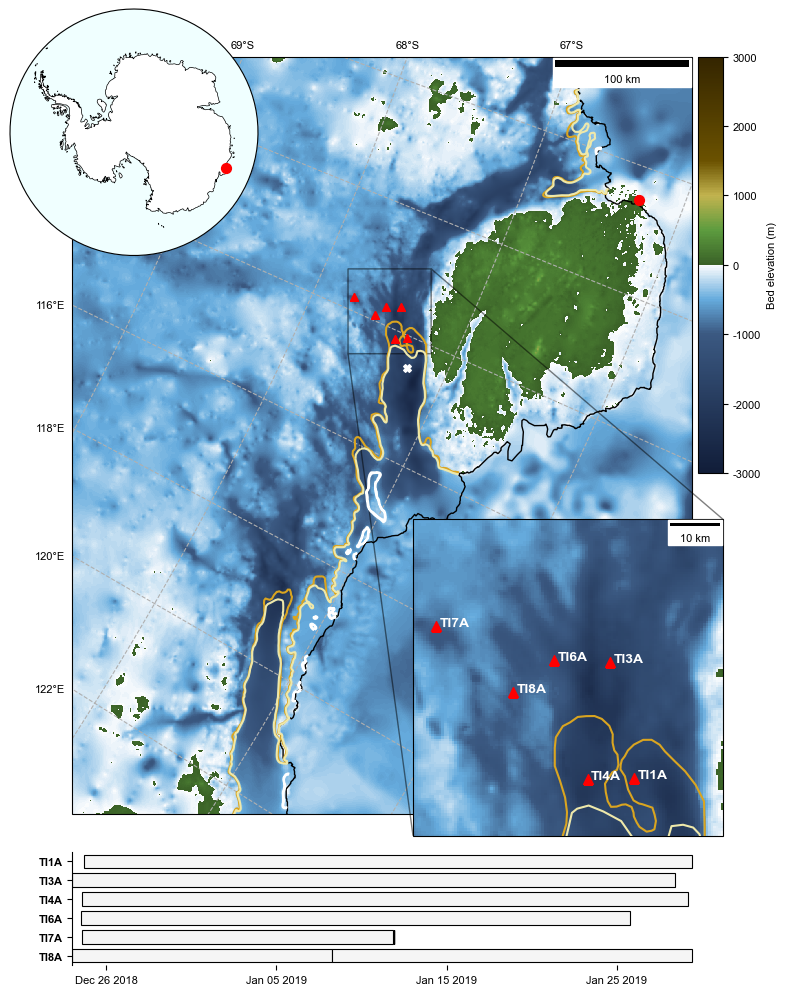

In [23]:
wgs84 = ccrs.PlateCarree()
stereo = ccrs.epsg(3031)

# --- Reproject grounding line records ---
up_ll = [reproject_geom(rec.geometry) for rec in up]
dn_ll = [reproject_geom(rec.geometry) for rec in dn]
isl_ll = [reproject_geom(rec.geometry) for rec in isl]

# --- Reproject coastline if needed ---
coast_ll = [reproject_geom(geom) for geom in coastline_data.geometries()]

# --- Figure ---
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())



ax.set_extent([110, 121, -68.4, -66], crs = wgs84) # Define map extent in axis via [minlon, maxlon, minlat, maxlat]

#ax_spare = fig.add_subplot(122, projection = ccrs.SouthPolarStereo()) # Uncomment this if you want to see how Obspy handles multiple subplots!

# Add BedMachine & MEaSUREs data to map & style (as before)
#bedmachine_data = nc.Dataset(bedmachine_file)
#pcm = ax.pcolormesh(bedmachine_data.variables['x'][::10], bedmachine_data.variables['y'][::10], bedmachine_data.variables['bed'][::10,::10],
                    #cmap = cmap_bedmachine(), transform = ccrs.epsg(3031), vmin = -3000, vmax = 3000) # N.B. Rerun custom colormaps block above

# Raster (stays in EPSG:3031)
pcm = ax.pcolormesh(x_crop, y_crop, bed_crop,cmap=cmap_bedmachine(),transform=stereo,vmin=-3000, vmax=3000,zorder=1)


# Grounding lines (now in lon/lat)
ax.add_geometries(up_ll, crs=wgs84, facecolor="none", edgecolor="goldenrod", linewidth=1.5, zorder=10)
ax.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=10)
ax.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5, zorder=10)

# Coastline
ax.add_geometries(coast_ll, crs=wgs84, facecolor="none", edgecolor="black", linewidth=1, zorder=5)

# Stations (already lon/lat)
station_df.plot.scatter(ax=ax, x="Longitude", y="Latitude",transform=wgs84, c="red", marker="^", s=30, zorder=20)


#ax.gridlines(draw_labels = True, linestyle = '--')

gl = ax.gridlines(crs=wgs84, draw_labels = {'top':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)


station_df.plot.scatter(ax = ax, x = 'Longitude', y = 'Latitude', transform = wgs84, c = 'red', marker = '^', s = 30,zorder=10)

ant_ax = ax.inset_axes(bounds = [-0.1, 0.7, 0.4, 0.4], transform = ax.transAxes, projection = map_proj)
ant_ax.set_extent([0,360,-90,-60],crs=wgs84)
ant_ax.coastlines(lw=0.5)
ant_ax.add_feature(ctp.feature.OCEAN,facecolor='azure')
#ant_ax.add_geometries(coastline_data.geometries(), ccrs.epsg(3031), facecolor='white', edgecolor = 'black',lw=0.3)

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts*radius + center)
ant_ax.set_boundary(circle, transform = ant_ax.transAxes)

#ant_ax.scatter(centre[0],centre[1],s=30,marker='o',color='red',transform=wgs84,zorder=5)
ant_ax.scatter(casey_lon,casey_lat,s=50,marker='o',color='red',transform=wgs84,zorder=10)

scalebar = ScaleBar(0.001, "km", fixed_value=100)
ax.add_artist(scalebar)

inset_ax1 = ax.inset_axes(bounds = [1.01, 0.45, 0.04, 0.55], transform = ax.transAxes)
clb = fig.colorbar(pcm, cax = inset_ax1)
clb.set_label('Bed elevation (m)')
inset_ax1.set_yticks([-3000,-2000,-1000,0,1000,2000,3000],['-3000','-2000','-1000','0','1000','2000','3000'])

inset_ax2 = ax.inset_axes(bounds = [0.55, -0.07, 0.5, 0.5], transform = ax.transAxes, projection = map_proj)
inset_ax2.set_extent([113.2, 114.3, -67.7, -67.3], crs = wgs84)
ax.indicate_inset_zoom(inset_ax2, edgecolor = 'black') # indicate on main axes the inset axes
inset_ax2.pcolormesh(x_crop, y_crop, bed_crop,cmap=cmap_bedmachine(),transform=stereo,vmin=-3000, vmax=3000,zorder=1) # N.B. Rerun custom colormaps block above
#inset_ax2.add_geometries(groundingline_data2.geometries(), wgs84, facecolor = 'none', edgecolor = 'yellow', linewidth = 1)
#inset_ax2.add_geometries(groundingline_data.geometries(), ccrs.epsg(3031), facecolor = 'none', edgecolor = 'white', linewidth = 1,linestyle='--')

# Grounding lines (now in lon/lat)
inset_ax2.add_geometries(up_ll, crs=wgs84, facecolor="none", edgecolor="goldenrod", linewidth=1.5, zorder=10)
inset_ax2.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=10)
inset_ax2.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5, zorder=10)

inset_ax2.add_geometries(coast_ll, crs=wgs84, facecolor="none", edgecolor="black", linewidth=1, zorder=5)


#inset_ax2.add_geometries(grounding_zone_data.geometries(), ccrs.epsg(3031), facecolor = 'none', edgecolor = 'yellow', linewidth = 1.2)


station_df.plot.scatter(ax = inset_ax2, x = 'Longitude', y = 'Latitude', transform = wgs84, c = 'red', marker = '^', s = 50,zorder=10)


for i, row in station_df.iterrows():
    station_ll = map_proj.transform_point(row['Longitude'],row['Latitude'],wgs84)
    #inset_ax2.annotate(fr"\textbf{{{row['Station']}}}",station_ll,c='white',zorder=15)
    inset_ax2.annotate(row['Station'],station_ll,c='white',zorder=15,weight='bold',fontsize=10,xytext=(0.25,0), textcoords='offset fontsize')

tide_xy = map_proj.transform_point(tide_lon,tide_lat,wgs84)
casey_xy = map_proj.transform_point(casey_lon,casey_lat,wgs84)

ax.scatter(tide_xy[0],tide_xy[1],color='white',marker='X',s=30,zorder=10)
ax.scatter(casey_xy[0],casey_xy[1],color='red',marker='o',s=50,zorder=10)


scalebar2 = ScaleBar(0.001, "km", fixed_value=10)
inset_ax2.add_artist(scalebar2)

avail = pd.read_csv('totten_stream_availability.csv')

avail_ax = ax.inset_axes(bounds = [0, -0.2, 1.05, 0.15], transform = ax.transAxes)

i = 0
labels = []
coords = []

rows = []

for i, row in station_df.iterrows():
   

    subset = avail[(avail['Station']==row['Station']) & (avail['Channel']=='CHZ')]
    
    starts = subset['Start'].to_numpy()
    ends = subset['End'].to_numpy()

    short_start = []
    short_end = []
    short_start.append(starts[0])

    for i, start in enumerate(starts[1:]):
        if start != ends[i]:
            short_start.append(start)
            short_end.append(ends[i])

    short_end.append(ends[-1])

    for i in range(len(short_start)):
        rows.append({'Station':row['Station'],'Start':short_start[i],'End':short_end[i]})

df = pd.DataFrame(data=rows)

for i, row in station_df.iterrows():
    subset = df[(df['Station']==row['Station'])]
    start = pd.to_datetime(subset['Start'])# + pd.Timedelta(hours=chunk.time_offset)
    end = pd.to_datetime(subset['End']) #+ pd.Timedelta(hours=chunk.time_offset)
    duration = end - start

    color='whitesmoke'
        
    avail_ax.barh(-i,duration,height=0.7,left=start,facecolor=color,edgecolor='black',lw=0.8)
    coords.append(-i)
    #labels.append(fr"\textbf{{{row['Station']}}}")
    labels.append(row['Station'])

avail_ax.set_yticks(coords)
avail_ax.set_yticklabels(labels,weight='bold')
avail_ax.spines['right'].set_visible(False)
#avail_ax.spines['left'].set_visible(False)
avail_ax.spines['top'].set_visible(False)
avail_ax.spines['bottom'].set_visible(False)

myFmt = DateFormatter("%b %d %Y",usetex=False)
avail_ax.xaxis.set_major_formatter(myFmt)
avail_ax.xaxis.set_major_locator(DayLocator(interval=10))

#_set_xaxis_obspy_dates(avail_ax)
avail_ax.set_ylim(-5.5,0.5)

plt.show();

fig.savefig(os.path.join(cloud_path,'A_GZ_Totten_Network.png'),bbox_inches='tight',dpi=400)

In [11]:
#can try plotting out the coalescence function or confidence ellipses on the map...
from iqvis import spatial_analysis as sa
from obspy.geodetics import degrees2kilometers, kilometers2degrees

path = '/Users/jmagyar/Documents/TottenData'

coal_path = os.path.join(path,'coalescence')
coal_file = np.load(os.path.join(coal_path,'coalescence_function_'+str(34)+'.npz'))
x, y, z, t, coal = coal_file['x'], coal_file['y'], coal_file['z'], coal_file['t'], coal_file['coal']
fit, uncertainties, centres = sa.UncertaintyQuantBackM(x,y,z,t,inv.select(station='TI?A'),coal,time_slice=True)
sta_xy, centre = sa.CartesianStations(inv.select(station='TI?A'))

x_ind, y_ind, z_ind, t_ind = np.unravel_index(np.argmax(coal),coal.shape)

#stacked_coalescence = np.max(summed_PS_obj,axis=(0,1,2))
#t_ind = np.argmax(stacked_coalescence)

coal_slice = coal[:,:,:,t_ind]

masks = {0.5:sa.ConnectedCoalescenceMask(coal_slice,thresh=0.5),0.75:sa.ConnectedCoalescenceMask(coal_slice,thresh=0.75)}

In [12]:
lon_grid = np.array([kilometers2degrees(x_km,radius=6371.0*np.cos(np.deg2rad(centre[0]))) + centre[1] for x_km in x])
lat_grid = np.array([kilometers2degrees(y_km) + centre[0] for y_km in y])

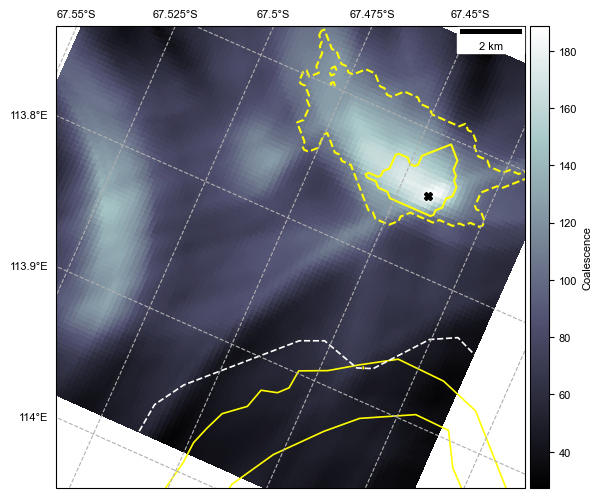

In [13]:
# Generate Cartopy figure instance
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection = ccrs.SouthPolarStereo())
ax.set_extent([113.70, 113.95, -67.52, -67.42], crs = wgs84) # Define map extent in axis via [minlon, maxlon, minlat, maxlat]

#ax_spare = fig.add_subplot(122, projection = ccrs.SouthPolarStereo()) # Uncomment this if you want to see how Obspy handles multiple subplots!

# Add BedMachine & MEaSUREs data to map & style (as before)
#bedmachine_data = nc.Dataset(bedmachine_file)

groundingline_data = shpreader.Reader(groundingline_file)
coastline_data = shpreader.Reader(coastline_file)
ax.add_geometries(groundingline_data2.geometries(), wgs84, facecolor = 'none', edgecolor = 'yellow', linewidth = 1.2)
ax.add_geometries(groundingline_data.geometries(), ccrs.epsg(3031), facecolor = 'none', edgecolor = 'white', linewidth = 1.2,linestyle='--')
ax.add_geometries(coastline_data.geometries(), ccrs.epsg(3031), facecolor = 'none', edgecolor = 'black')

pcm = ax.pcolormesh(lon_grid,lat_grid,np.sum(coal_slice,axis=2).T,transform=wgs84,cmap='bone')
ax.contour(lon_grid,lat_grid,masks[0.75].any(axis=2).T,colors='yellow',transform=wgs84)
ax.contour(lon_grid,lat_grid,masks[0.5].any(axis=2).T,linestyles='--',colors='yellow',transform=wgs84)
ax.plot(lon_grid[x_ind],lat_grid[y_ind],marker='X',color='black',transform=wgs84)


inset_ax1 = ax.inset_axes(bounds = [1.01, 0.0, 0.04, 1], transform = ax.transAxes)
clb = fig.colorbar(pcm, cax = inset_ax1)
clb.set_label('Coalescence')

gl = ax.gridlines(crs=wgs84, draw_labels = {'top':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)

#station_df.plot.scatter(ax = ax, x = 'Longitude', y = 'Latitude', transform = wgs84, c = 'red', marker = '^', s = 30)
#icequake_loc.plot.scatter(ax = ax, x = 'PS_lon', y = 'PS_lat', transform = wgs84, c = 'white',marker='x', s = 25)


#for i, row in icequake_loc.iterrows():
    #label = row['Label']
#    event_ll = map_proj.transform_point(row['PS_lon'],row['PS_lat'],wgs84)
#    ax.annotate(str(i),event_ll,color='white',weight='bold',ha='center',va='top',xytext=(0, -0.7), textcoords='offset fontsize')


scalebar = ScaleBar(1, "m", length_fraction=0.25)
ax.add_artist(scalebar)


#for i, row in station_df.iterrows():
#    station_ll = map_proj.transform_point(row['Longitude'],row['Latitude'],wgs84)
#    ax.annotate(row['Station'],station_ll,c='white',weight='bold')

plt.show();

fig.savefig(os.path.join(cloud_path,'CoalescenceSurface.png'),bbox_inches='tight',dpi=400)

In [14]:
migration_results = pd.read_csv(os.path.join(coal_path,'backmigration_results' + '.csv'),index_col=0)
cluster_labels = pd.read_csv(os.path.join(path,'cluster_labels' + '.csv'),index_col=0)
good_migration_results = migration_results.drop([116,117],axis=0)
good_migration_results

,max_coal,med_Mw,X,Y,Z,t,lon,lat,cX,cY,cZ,clon,clat,sX,sY,sZ
44,5.597450,1.201951,-1.666667,3.484848,0.163265,7.20,113.826776,-67.471728,-2.040274,4.171264,1.833781,113.817995,-67.465555,0.680662,0.986252,1.113823
54,4.212386,0.660307,-5.909091,-1.515152,3.346939,7.00,113.727065,-67.516694,-5.843600,-1.181265,2.819091,113.728604,-67.513691,0.755195,0.558150,0.553765
39,4.783320,0.988962,-3.787879,6.818182,0.000000,6.50,113.776920,-67.441750,-4.126012,6.842250,1.718677,113.768973,-67.441534,0.525849,0.797532,1.099932
34,5.336974,1.333628,-5.151515,6.818182,1.795918,7.65,113.744870,-67.441750,-5.315674,6.511935,1.543289,113.741012,-67.444505,0.418584,0.521331,1.018574
33,5.744149,1.234352,-5.454545,5.606061,0.163265,7.75,113.737748,-67.452651,-6.238415,4.800362,1.573252,113.719324,-67.459897,0.647046,0.766421,0.997906
32,4.577197,1.363427,-4.090909,1.666667,1.224490,6.80,113.769798,-67.488079,-4.447459,1.604215,1.659235,113.761418,-67.488641,0.423148,0.473620,1.021132
31,5.031272,1.433000,-3.484848,7.121212,0.326531,7.25,113.784043,-67.439025,-4.003726,6.705205,2.002976,113.771847,-67.442766,0.701039,0.444032,1.186098
43,6.998456,1.340721,-1.212121,3.333333,1.306122,7.00,113.837459,-67.473090,-1.645567,4.050525,1.969151,113.827272,-67.466641,0.475507,0.825622,1.078024


In [17]:
cmap = plt.colormaps.get_cmap('autumn')

min_coal = good_migration_results['max_coal'].min()
max_coal = good_migration_results['max_coal'].max()

minMw = good_migration_results['med_Mw'].min()
maxMw = good_migration_results['med_Mw'].max()

cb_min = int(min_coal)
cb_max = int(max_coal+1)

def cb_map(val,cb_min,cb_max):
    mapped = (val - cb_min) / (cb_max - cb_min)
    return mapped

def size_map(val,min_val,max_val,min_size=40,max_size=80):
    mapped = (val - min_val) / (max_val - min_val)
    size = min_size + mapped * (max_size - min_size) 
    return size

In [18]:
icecap_file = directory + 'UTIG_2010_ICECAP_AIR_BM3.csv'
eagle_file = directory + 'UTIG_2015_EAGLE_AIR_BM3.csv'
pric_file = directory + 'PRIC_2015_CHA1_AIR_BM3.csv'
ingv_file = directory + 'INGV_2003_Talos-Dome_AIR_BM3.csv'


icecap2010 = pd.read_csv(icecap_file,sep=',',na_values=-9999,skiprows=18)
eagle2015 = pd.read_csv(eagle_file,sep=',',na_values=-9999,skiprows=18)
pric2015 = pd.read_csv(pric_file,sep=',',na_values=-9999,skiprows=18)
ingv2003 = pd.read_csv(ingv_file,sep=',',na_values=-9999,skiprows=18)

#crop out the extent of the map...
icecap2010 = icecap2010[(icecap2010['longitude (degree_east)'] >= 113.65) & (icecap2010['longitude (degree_east)'] <= 114) & (icecap2010['latitude (degree_north)'] >= -67.52) & (icecap2010['latitude (degree_north)'] <= -67.40)]
eagle2015 = eagle2015[(eagle2015['longitude (degree_east)'] >= 113.65) & (eagle2015['longitude (degree_east)'] <= 114) & (eagle2015['latitude (degree_north)'] >= -67.52) & (eagle2015['latitude (degree_north)'] <= -67.40)]
pric2015 = pric2015[(pric2015['longitude (degree_east)'] >= 113.65) & (pric2015['longitude (degree_east)'] <= 114) & (pric2015['latitude (degree_north)'] >= -67.52) & (pric2015['latitude (degree_north)'] <= -67.40)]
ingv2003 = ingv2003[(ingv2003['longitude (degree_east)'] >= 113.65) & (ingv2003['longitude (degree_east)'] <= 114) & (ingv2003['latitude (degree_north)'] >= -67.52) & (ingv2003['latitude (degree_north)'] <= -67.40)]

In [19]:
GL1335a = icecap2010[icecap2010['trajectory_id'] == 'IR2HI2_2010364_ASB_JKB2d_GL1335a']
GL1335b = icecap2010[icecap2010['trajectory_id'] == 'IR2HI2_2012336_ASB_JKB2h_GL1335b']
Y40a = icecap2010[icecap2010['trajectory_id'] == 'IR2HI2_2011013_TOT_JKB2d_Y40a']

for df in [GL1335a,GL1335b,Y40a]:
    trans_coords = map_proj.transform_points(wgs84,df['longitude (degree_east)'].to_numpy(),df['latitude (degree_north)'].to_numpy())
    df['X'] = trans_coords[:,0]
    df['Y'] = trans_coords[:,1]

/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_50616/3927354308.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['X'] = trans_coords[:,0]
/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_50616/3927354308.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Y'] = trans_coords[:,1]
/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_50616/3927354308.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

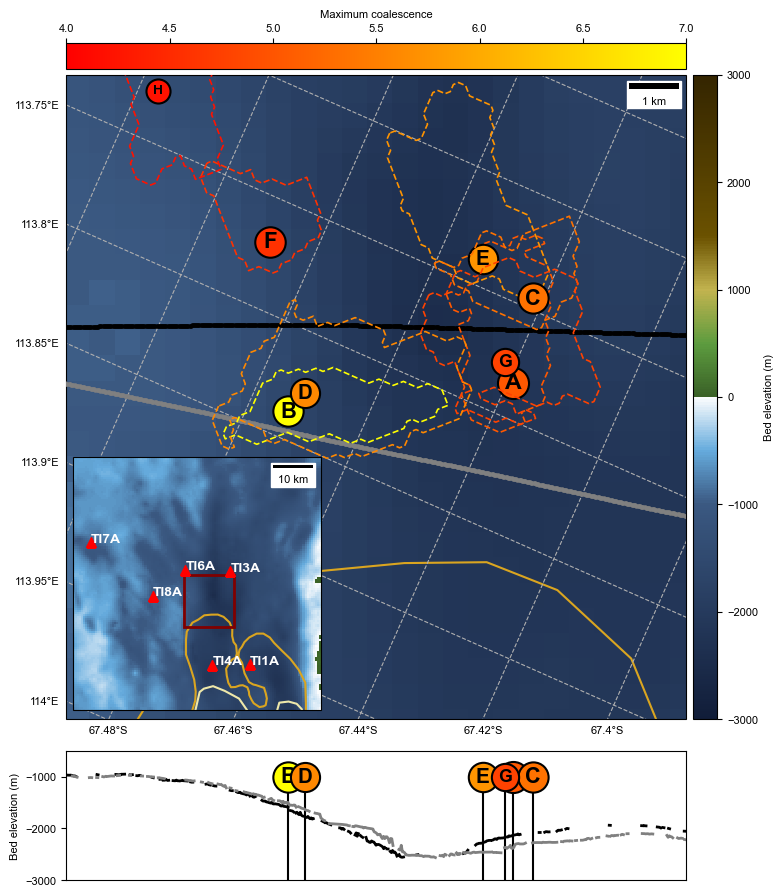

In [22]:
#same as above but with inset plot from network figure showing context relative to stations and subglacial trough...
fig = plt.figure(figsize = (8,10))
ax = fig.add_subplot(111, projection = ccrs.SouthPolarStereo())
#ax.set_extent([113.70, 113.95, -67.52, -67.42], crs = wgs84) # Define map extent in axis via [minlon, maxlon, minlat, maxlat]
ax.set_extent([113.70, 113.93, -67.5, -67.42], crs = wgs84)


inset_ax = ax.inset_axes(bounds = [0.01, 0.01, 0.4, 0.4], transform = ax.transAxes, projection = map_proj)
inset_ax.set_extent([113.2, 114.3, -67.7, -67.3],crs=wgs84)

cb_ax1 = ax.inset_axes(bounds = [1.01, 0.0, 0.04, 1], transform = ax.transAxes)
cb_ax2 = ax.inset_axes(bounds = [0.0,1.01,1,0.04],transform=ax.transAxes)

bed_ax = ax.inset_axes(bounds = [0.0,-0.25,1,0.2],transform=ax.transAxes,sharex=ax)




pcm = ax.pcolormesh(x_crop, y_crop, bed_crop,
                    cmap = cmap_bedmachine(), transform = ccrs.epsg(3031), vmin = -3000, vmax = 3000) # N.B. Rerun custom colormaps block above

inset_ax.pcolormesh(x_crop, y_crop, bed_crop,
                    cmap = cmap_bedmachine(), transform = ccrs.epsg(3031), vmin = -3000, vmax = 3000) # N.B. Rerun custom colormaps block above



inset_indicator = inset_ax.indicate_inset_zoom(ax, edgecolor = 'maroon',alpha=1,linewidth=2) # indicate on main axes the inset axes

for connector in inset_indicator.connectors:
    connector.set_visible(False)


ax.add_geometries(up_ll, crs=wgs84, facecolor="none", edgecolor="goldenrod", linewidth=1.5)
ax.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5)
ax.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5)

inset_ax.add_geometries(up_ll, crs=wgs84, facecolor="none", edgecolor="goldenrod", linewidth=1.5)
inset_ax.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5)
inset_ax.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5)

#inset_ax2.add_geometries(grounding_zone_data.geometries(), ccrs.epsg(3031), facecolor = 'none', edgecolor = 'yellow', linewidth = 1.2)


station_df.plot.scatter(ax = inset_ax, x = 'Longitude', y = 'Latitude', transform = wgs84, c = 'red', marker = '^', s = 50,zorder = 5)


for i, row in station_df.iterrows():
    station_ll = map_proj.transform_point(row['Longitude'],row['Latitude'],wgs84)
    #inset_ax.annotate(fr"\textbf{{{row['Station']}}}",station_ll,c='white',weight='bold',zorder=5,size=10)
    inset_ax.annotate(row['Station'],station_ll,c='white',weight='bold',zorder=5,size=10)


for i, row in good_migration_results.iterrows():

    coal_file = np.load(os.path.join(coal_path,'coalescence_function_'+str(i)+'.npz'))
    x, y, z, t, coal = coal_file['x'], coal_file['y'], coal_file['z'], coal_file['t'], coal_file['coal']
    x_ind, y_ind, z_ind, t_ind = np.unravel_index(np.argmax(coal),coal.shape)
    coal_slice = coal[:,:,:,t_ind]
    fit, uncertainties, centres = sa.UncertaintyQuantBackM(x,y,z,t,inv.select(station='TI?A'),coal,time_slice=True)
    masks = {0.5:sa.ConnectedCoalescenceMask(coal_slice,thresh=0.5),0.75:sa.ConnectedCoalescenceMask(coal_slice,thresh=0.75)}    
    lon_grid = np.array([kilometers2degrees(x_km,radius=6371.0*np.cos(np.deg2rad(centre[0]))) + centre[1] for x_km in x])
    lat_grid = np.array([kilometers2degrees(y_km) + centre[0] for y_km in y])

    max_coal = row['max_coal']
    med_Mw = row['med_Mw']

    color = cmap(cb_map(max_coal,cb_min,cb_max))
    size = size_map(med_Mw,minMw,maxMw,min_size=300,max_size=500)
    ax.contour(lon_grid,lat_grid,masks[0.75].any(axis=2).T,colors=color,transform=wgs84,linestyles='--',linewidths=1.2,zorder=i+5)
    ax.scatter(row['lon'],row['lat'],transform=wgs84,color=color,edgecolors='black',linewidths=1.5,marker='o',s=size,zorder=i+5.1) #s = mag * fac
    label = cluster_labels['Label'][i]
    event_ll = map_proj.transform_point(row['lon'],row['lat'],wgs84)
    #ax.annotate(label,event_ll,color='black',weight='black',ha='center',va='center',xytext=(0.05, -0.05), textcoords='offset fontsize',size=size/30,zorder=i+5.2)
    ax.annotate(label,event_ll,color='black',weight='black',ha='center',va='center',size=size/30,zorder=i+5.2)


    if label in ['A','B','C','D','E','G']:
        bed_ax.scatter(event_ll[0],-1000,color=color,edgecolors='black',linewidths=1.5,marker='o',s=size,zorder=i+5.1)
        #bed_ax.annotate(label,(event_ll[0],-1000),color='black',weight='black',ha='center',va='center',xytext=(0.05, -0.05), textcoords='offset fontsize',size=size/30,zorder=i+5.2)
        bed_ax.annotate(label,(event_ll[0],-1000),color='black',weight='black',ha='center',va='center',size=size/30,zorder=i+5.2)
        bed_ax.vlines(event_ll[0],ymin=-3000,ymax=-1000,colors='black')

#good_migration_results.plot.scatter(ax = ax, x = 'lon', y = 'lat', transform = wgs84, c = 'white',marker='x', s = 40)
coal_cb = fig.colorbar(plt.cm.ScalarMappable(plt.Normalize(cb_min,cb_max),cmap='autumn'),cax=cb_ax2,orientation='horizontal')
coal_cb.set_label('Maximum coalescence')
coal_cb.ax.xaxis.set_ticks_position('top')
coal_cb.ax.xaxis.set_label_position('top')
#cb_ax2.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)


clb = fig.colorbar(pcm, cax = cb_ax1)
clb.set_label('Bed elevation (m)')
gl = ax.gridlines(crs=wgs84, draw_labels = {'bottom':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)


scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.5,fixed_value=10)
inset_ax.add_artist(scalebar)

scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.5,fixed_value=1)
ax.add_artist(scalebar)

#for spine in ax.spines.values():
#    spine.set_linewidth(2)

#for spine in inset_ax.spines.values():
#    spine.set_linewidth(1.5)

bed_ax.plot(Y40a['X'],Y40a['bedrock_altitude (m)'],color='k',lw=2,label='Y40a')
bed_ax.plot(GL1335b['X'],GL1335b['bedrock_altitude (m)'],color='grey',lw=2,label='GL1335b')

bed_ax.set_ylim(-3000,-500)
bed_ax.set_yticks([-3000,-2000,-1000])#,labels=['-3000','-2000','-1000'])
bed_ax.set_xticks([])
bed_ax.set_ylabel('Bed elevation (m)')

#bed_ax.legend()

#for spine in bed_ax.spines.values():
#    spine.set_linewidth(2)

#fmt = matplotlib.ticker.StrMethodFormatter("{x}")
#cb_ax1.yaxis.set_major_formatter(fmt)
#cb_ax2.xaxis.set_major_formatter(fmt)

GL1335b.plot.scatter(ax = ax, x = 'longitude (degree_east)', y = 'latitude (degree_north)', transform = wgs84,c='grey', marker = 'o', s = 5,zorder = 5)
Y40a.plot.scatter(ax = ax, x = 'longitude (degree_east)', y = 'latitude (degree_north)', transform = wgs84,c='black', marker = 'o', s = 5,zorder = 5)

fig.savefig(os.path.join(cloud_path,'A_Radar_Migration_Locations.png'),bbox_inches='tight',dpi=400)